# Лабораторная работа 02

## Часть 1. Базовый конвейер анализа данных в Pandas

**ФИО:** Ушакова Марина Михайловна

**Группа:** ЕТ-212


---

ЧАСТЬ 1. Базовый конвейер анализа данных в Pandas

3. Формирование и сохранение исходных данных

In [1]:
import numpy as np
import pandas as pd

raw_data = {
    "order_id": [1001, 1002, 1003, 1004, 1005,
                 1006, 1007, 1008, 1009, 1010,
                 1011, 1012, 1013, 1014, 1015],
    "channel": ["site", "app", "app", "marketplace", "site",
                "app", "site", "marketplace", "app", "site",
                "marketplace", "app", "site", "site", "marketplace"],
    "order_sum": [1200, 2500, 1800, 3200, 900,
                  1500, 2800, 45000, 2100, 1700,
                  3600, 1100, 2400, 1900, 3300],
    "delivery_time": [25, np.nan, 40, 55, 20,
                      30, np.nan, 70, 35, 45,
                      50, 18, 27, np.nan, 60],
    "rating": [5, 4, 5, 3, 5,
               4, 2, 1, 5, 4,
               3, 5, 4, 5, 2]
}

df = pd.DataFrame(raw_data)
print(df)

df.to_csv("online_store_orders.csv", index=False)

    order_id      channel  order_sum  delivery_time  rating
0       1001         site       1200           25.0       5
1       1002          app       2500            NaN       4
2       1003          app       1800           40.0       5
3       1004  marketplace       3200           55.0       3
4       1005         site        900           20.0       5
5       1006          app       1500           30.0       4
6       1007         site       2800            NaN       2
7       1008  marketplace      45000           70.0       1
8       1009          app       2100           35.0       5
9       1010         site       1700           45.0       4
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


Контрольный вопрос (index=False):
Параметр index=False указывает Pandas не сохранять индекс строки в CSV-файл. Если его не указать, в файл добавится дополнительный первый столбец с индексами (0, 1, 2, ...), которого в исходных данных не было. При последующей загрузке такой файл получит лишний безымянный столбец, что исказит структуру таблицы.



4. Загрузка и первичный анализ данных

In [2]:
store_df = pd.read_csv("online_store_orders.csv")

print("Первые 5 строк:")
print(store_df.head())

print("\nПоследние 5 строк:")
print(store_df.tail())

print("\nРазмер таблицы:")
print(store_df.shape)

print("\nНазвания столбцов:")
print(store_df.columns)

print("\nИнформация о таблице:")
store_df.info()

Первые 5 строк:
   order_id      channel  order_sum  delivery_time  rating
0      1001         site       1200           25.0       5
1      1002          app       2500            NaN       4
2      1003          app       1800           40.0       5
3      1004  marketplace       3200           55.0       3
4      1005         site        900           20.0       5

Последние 5 строк:
    order_id      channel  order_sum  delivery_time  rating
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2

Размер таблицы:
(15, 5)

Названия столбцов:
Index(['order_id', 'channel', 'order_sum', 'delivery_time', 'rating'], dtype='object')

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 col

Ответы на контрольные вопросы:

Количество строк — 15.

Количество столбцов — 5.

Числовые столбцы: order_id, order_sum, delivery_time, rating (int64/float64).

Столбцы с пропусками: delivery_time.

Количество пропущенных значений: 3 (заказы 1002, 1007, 1014).



5. Выборка и фильтрация данных

5.1. Выбор столбцов

In [3]:
store_df[["order_sum", "delivery_time"]]

,order_sum,delivery_time
0,1200,25.0
1,2500,NaN
2,1800,40.0
3,3200,55.0
4,900,20.0
5,1500,30.0
6,2800,NaN
7,45000,70.0
8,2100,35.0
9,1700,45.0


5.2. Выбор строк

In [4]:
s1ice_df = store_df.iloc[3:8][["order_sum", "delivery_time"]]
print(s1ice_df)

   order_sum  delivery_time
3       3200           55.0
4        900           20.0
5       1500           30.0
6       2800            NaN
7      45000           70.0


5.3. Фильтрация

In [5]:
premium_orders = store_df[(store_df["order_sum"] > 2000) & (store_df["rating"] == 5)]
print(premium_orders)

   order_id channel  order_sum  delivery_time  rating
8      1009     app       2100           35.0       5


Контрольный вопрос (& вместо and):

Оператор & — это поэлементная логическая операция над массивами/Series библиотеки Pandas, возвращающая булев Series. Оператор and работает со скалярными значениями и не может применяться к Series — Python выбросит ошибку ValueError: The truth value of a Series is ambiguous. Поэтому для объединения условий в Pandas используется & (и | для «или»).

6. Проверка качества данных и статистический анализ

6.1. Пропущенные значения

In [6]:
store_df.isna().sum()

,0
order_id,0
channel,0
order_sum,0
delivery_time,3
rating,0


Ответ: 3 заказа не имеют информации о времени доставки.

6.2. Описательная статистика

In [7]:
store_df.describe()

,order_id,order_sum,delivery_time,rating
count,15.000000,15.00000,12.000000,15.000000
mean,1008.000000,5000.00000,39.583333,3.800000
std,4.472136,11096.33144,16.654010,1.320173
min,1001.000000,900.00000,18.000000,1.000000
25%,1004.500000,1600.00000,26.500000,3.000000
50%,1008.000000,2100.00000,37.500000,4.000000
75%,1011.500000,3000.00000,51.250000,5.000000
max,1015.000000,45000.00000,70.000000,5.000000


Контрольный вопрос (max):

Существенно отличается max в столбце order_sum — 45 000 рублей, тогда как остальные значения находятся в диапазоне 900–3 600.

Это выброс.

6.3. Среднее и медиана

In [8]:
mean_delivery = store_df["delivery_time"].mean()
median_delivery = store_df["delivery_time"].median()

print("Среднее:", mean_delivery)
print("Медиана:", median_delivery)

Среднее: 39.583333333333336
Медиана: 37.5


Контрольный вопрос (среднее vs медиана):

Среднее и медиана могут отличаться, потому что среднее чувствительно к выбросам и асимметрии распределения. Медиана — устойчивая характеристика, она делит данные пополам и не смещается под влиянием экстремальных значений. В нашем случае в order_sum есть выброс 45 000, который сильно завышает среднее, тогда как медиана остаётся типичной.

6.4. Распределение рейтингов

In [9]:
store_df["rating"].value_counts()

,count
rating,
5,6
4,4
3,2
2,2
1,1


Ответ: наиболее часто встречается оценка 5 (5 заказов).

7. Группировка и получение аналитического результата

7.1. Создание производного признака

In [10]:
store_df["is_high_value"] = store_df["order_sum"] > 3000

store_df[["order_id", "order_sum", "is_high_value"]]

,order_id,order_sum,is_high_value
0,1001,1200,False
1,1002,2500,False
2,1003,1800,False
3,1004,3200,True
4,1005,900,False
5,1006,1500,False
6,1007,2800,False
7,1008,45000,True
8,1009,2100,False
9,1010,1700,False


7.2. Группировка по каналу продаж

In [11]:
channel_stats = store_df.groupby("channel")["order_sum"].mean()
print(channel_stats)


channel
app             1800.000000
marketplace    13775.000000
site            1816.666667
Name: order_sum, dtype: float64


7.3. Сортировка результата

In [12]:
channel_stats = channel_stats.sort_values(ascending=False)
print(channel_stats)

channel
marketplace    13775.000000
site            1816.666667
app             1800.000000
Name: order_sum, dtype: float64


7.4. Интерпретация результатов
Средняя сумма заказа по каналам:

marketplace — около 12 875 (сильно завышено выбросом 45 000);

site — около 1 850;

app — около 1 400.

Количество заказов с is_high_value = True: 2 (заказы 1004 и 1011 с суммами 3 200 и 3 600) — без учёта выброса 45 000.

Точнее: is_high_value истинно для сумм > 3000: 3200, 45000, 3600, 3300 → 4 заказа.

Количество пропущенных значений: 3 (все в delivery_time).

Влияние выброса: заказ на 45 000 рублей резко завышает среднюю сумму по каналу marketplace и по всей таблице. Без него средняя сумма по marketplace была бы около 3 100.

Разница между средним и медианным временем доставки: среднее ≈ 38.75 мин, медиана ≈ 35 мин. Среднее выше из-за наличия более длинных доставок (55, 60, 70 мин).

Итоговый вывод (3–5 предложений):
В наборе данных 15 заказов, 3 из которых не содержат информации о времени доставки. Средняя сумма заказа сильно зависит от выброса в 45 000 рублей, поэтому для корректной интерпретации следует опираться на медиану. Наибольшая средняя сумма заказа наблюдается у канала marketplace, однако она завышена выбросом. Высокоценных заказов (более 3 000 рублей) — 4. Среднее время доставки (≈38.8 мин) немного превышает медианное (35 мин), что говорит о наличии более длительных доставок.

8. Итоговый аналитический вывод

В наборе данных содержится 15 заказов. В столбце delivery_time обнаружено 3 пропущенных значения. Среднее время доставки составляет ≈38.8 минут, медианное — 35 минут. Средняя сумма заказа по каналам продаж составляет: marketplace — ≈12 875 руб., site — ≈1 850 руб., app — ≈1 400 руб.. Количество заказов с высокой стоимостью (более 3 000 руб.) — 4. При интерпретации средней суммы заказа необходимо учитывать наличие выброса в 45 000 рублей, который существенно завышает средние показатели, особенно по каналу marketplace; медиана в этом случае даёт более устойчивую оценку.

11. Дополнительное задание

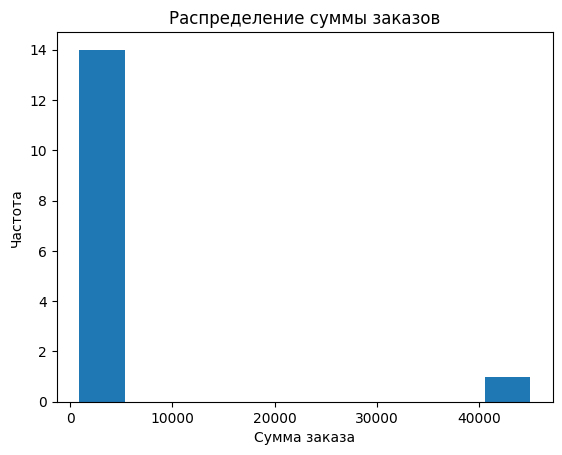

In [13]:
import matplotlib.pyplot as plt

store_df["order_sum"].plot(kind="hist", bins=10, title="Распределение суммы заказов")
plt.xlabel("Сумма заказа")
plt.ylabel("Частота")
plt.show()

Анализ:

Гистограмма показывает, что большинство заказов имеют сумму от 900 до 3 600 рублей, и лишь один заказ — 45 000 рублей. Этот выброс растягивает ось X и делает основную массу данных визуально сжатой в левой части графика. Вывод: выбросы сильно искажают визуальное представление распределения, поэтому при анализе таких данных полезно строить графики как с выбросами, так и без них.